# week 2 Day 5

- AFL Match Context Integration.

---

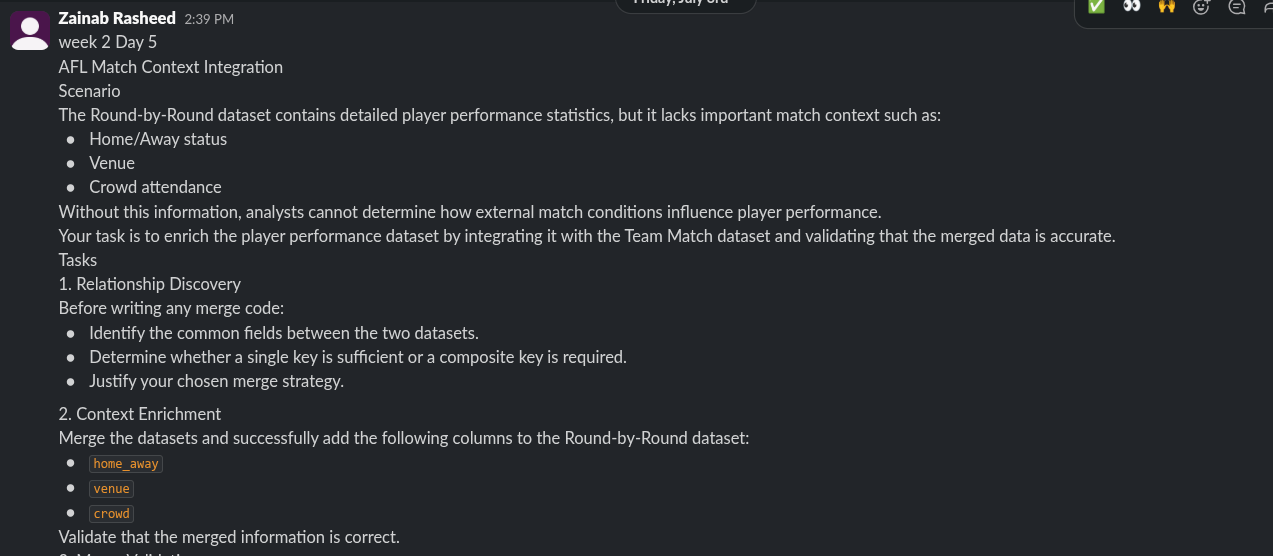

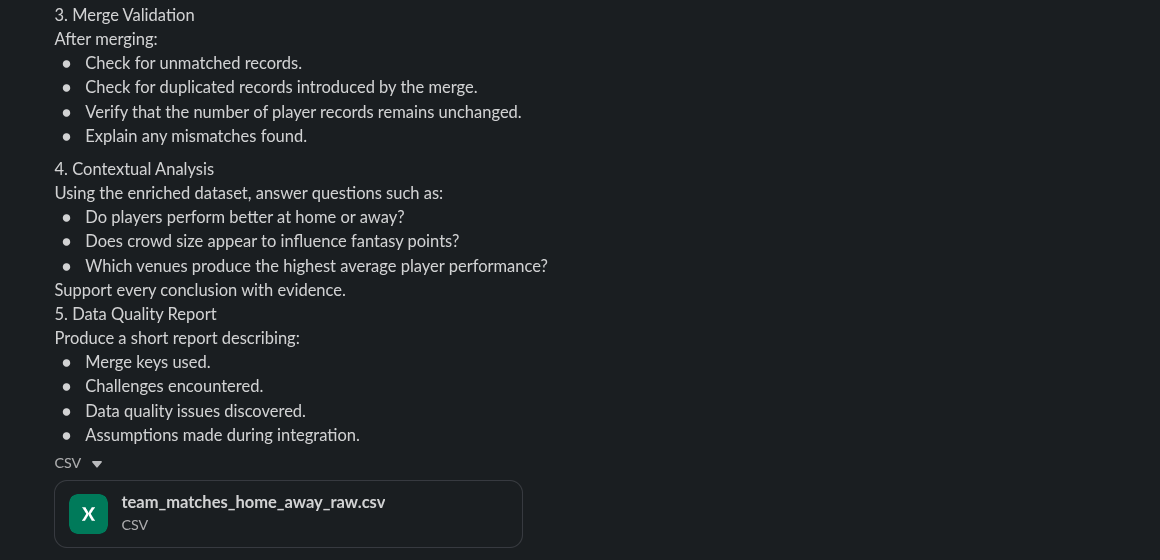

---


Scenario:
The Round-by-Round dataset contains detailed player performance statistics, but it lacks important match context such as:

    1. Home/Away status
    2. Venue
    3. Crowd attendance


Without this information, analysts cannot determine how external match conditions influence player performance.
Your task is to enrich the player performance dataset by integrating it with the Team Match dataset and validating that the merged data is accurate.


## Tasks
1. Relationship Discovery

Before writing any merge code:

- Identify the common fields between the two datasets.
- Determine whether a single key is sufficient or a composite key is required.
- Justify your chosen merge strategy.


2. Context Enrichment
Merge the datasets and successfully add the following columns to the Round-by-Round dataset:

- home_away
- venue
- crowd

Validate that the merged information is correct.


3. Merge Validation
After merging:

- Check for unmatched records.
- Check for duplicated records introduced by the merge.
- Verify that the number of player records remains unchanged.

Explain any mismatches found.


4. Contextual Analysis
Using the enriched dataset, answer questions such as:

- Do players perform better at home or away?
- Does crowd size appear to influence fantasy points?
- Which venues produce the highest average player performance?

Support every conclusion with evidence.

5. Data Quality Report
Produce a short report describing:

- Merge keys used.
- Challenges encountered.
- Data quality issues discovered.
- Assumptions made during integration.

---

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
match_df = pd.read_csv("../data/team_matches_home_away_raw.csv")
match_df.head()

,id,team_name,round,match_date,year,home_away,opponent,team_quarter_scores,team_score,opponent_quarter_scores,opponent_score,result,margin,venue,crowd,team_goals_kicked,team_behinds,opponent_goals_kicked,opponent_behinds
0,15807,Hawthorn Hawks,QF,1994-09-10,1994,A,North Melbourne Kangaroos,4.5 5.7 10.11 13.13 13.13 13.13,91,2.3 6.12 9.12 12.19 13.23 15.24,114,L,23,Waverley Park,38223.0,13,13,15,24
1,15808,North Melbourne Kangaroos,QF,1994-09-10,1994,H,Hawthorn Hawks,2.3 6.12 9.12 12.19 13.23 15.24,114,4.5 5.7 10.11 13.13 13.13 13.13,91,W,6,Waverley Park,38223.0,15,24,13,13
2,5646,North Melbourne Kangaroos,10,2008-05-31,2008,A,Brisbane Lions,2.2 6.2 12.3 15.8,98,4.7 11.12 15.17 18.21,129,L,-31,The Gabba,22118.0,15,8,18,21
3,8829,Sydney Swans,15,2017-06-30,2017,A,Melbourne Demons,1.8 5.15 8.16 11.19,85,4.0 4.1 5.4 7.8,50,W,35,Melbourne Cricket Ground,47464.0,11,19,7,8
4,8873,Sydney Swans,11,2019-06-01,2019,A,Geelong Cats,3.3 5.8 6.12 8.15,63,5.1 7.2 11.4 13.7,85,L,-22,GMHBA Stadium,29021.0,8,15,13,7


In [43]:
match_df.shape

(15808, 19)

In [44]:
match_df.columns

Index(['id', 'team_name', 'round', 'match_date', 'year', 'home_away',
       'opponent', 'team_quarter_scores', 'team_score',
       'opponent_quarter_scores', 'opponent_score', 'result', 'margin',
       'venue', 'crowd', 'team_goals_kicked', 'team_behinds',
       'opponent_goals_kicked', 'opponent_behinds'],
      dtype='str')

- some quick terminology searching
  - home game just means a game played at the primary stadium of a team
  - away game is a game played at the venue of the opponent
  - everything else should be consistent with the other datasets (total 20 teams, 2 of them have been gone since 1996, so 18 active teams. and 1 season is basically 1 year, and 1 season normally has 23 matches. a match is just a team vs team thing, a round is a team vs team across all 18 teams, so 9 matches equals 1 round basically. all this was consistent in the previous datasets, should be the same here)

## Cleaning
---


### Fixing team name feature

In [45]:
match_df["team_name"].nunique()

40

- Well, we have run into the first big problem already, there should be either 20 or 18 teams, not 40, this dataset needs cleaning just like the others, lets start on that I guess

In [46]:
print(match_df["team_name"].unique())

<StringArray>
[                 'Hawthorn Hawks',       'North Melbourne Kangaroos',
                    'Sydney Swans',                     'W. Bulldogs',
                  'Brisbane Lions',                   'Carlton Blues',
             'Collingwood Magpies',                'Essendon Bombers',
                   'Fitzroy Lions',               'Fremantle Dockers',
                    'Geelong Cats',                'Melbourne Demons',
                 'Richmond Tigers',                 'St Kilda Saints',
               'West Coast Eagles',               '\tSt Kilda Saints',
                   '\tW. Bulldogs',                '\tBrisbane Lions',
                 '\tCarlton Blues',              '\tEssendon Bombers',
     '\tNorth Melbourne Kangaroos',               '\tRichmond Tigers',
           '\tCollingwood Magpies',                  '\tSydney Swans',
             '\tWest Coast Eagles',                '\tBrisbane Bears',
              '\tMelbourne Demons',              '\t Adelaide C

- same stupid whitespace issue

In [47]:
match_df["team_name"] = match_df["team_name"].str.strip().str.title()
match_df["team_name"].nunique()

20

- ok, this is fixed now

In [48]:
match_df["team_name"].unique()

<StringArray>
[               'Hawthorn Hawks',     'North Melbourne Kangaroos',
                  'Sydney Swans',                   'W. Bulldogs',
                'Brisbane Lions',                 'Carlton Blues',
           'Collingwood Magpies',              'Essendon Bombers',
                 'Fitzroy Lions',             'Fremantle Dockers',
                  'Geelong Cats',              'Melbourne Demons',
               'Richmond Tigers',               'St Kilda Saints',
             'West Coast Eagles',                'Brisbane Bears',
                'Adelaide Crows',               'Gold Coast Suns',
 'Greater Western Sydney Giants',           'Port Adelaide Power']
Length: 20, dtype: str

- a new issue that claude just caught, the W Bulldogs team is named differently in our other datasets, lets just check quickly

In [49]:
seasonal_df = pd.read_csv("../Day-2/final/seasonal_stats.csv")
seasonal_df["team"].unique()

<StringArray>
[                 'Geelong Cats',               'St Kilda Saints',
                  'Sydney Swans',               'Gold Coast Suns',
                'Adelaide Crows',           'Port Adelaide Power',
                 'Carlton Blues',             'Fremantle Dockers',
                'Hawthorn Hawks',              'Western Bulldogs',
                'Brisbane Lions',     'North Melbourne Kangaroos',
 'Greater Western Sydney Giants',           'Collingwood Magpies',
             'West Coast Eagles',              'Essendon Bombers',
               'Richmond Tigers',              'Melbourne Demons',
                'Brisbane Bears',                 'Fitzroy Lions']
Length: 20, dtype: str

- yes, claude is right, its Western Bulldogs here, but in this new match_df its just W bulldogs. lets fix that

In [50]:
match_df["team_name"] = match_df["team_name"].replace({"W. Bulldogs": "Western Bulldogs"})

In [51]:
match_df["team_name"].unique()

<StringArray>
[               'Hawthorn Hawks',     'North Melbourne Kangaroos',
                  'Sydney Swans',              'Western Bulldogs',
                'Brisbane Lions',                 'Carlton Blues',
           'Collingwood Magpies',              'Essendon Bombers',
                 'Fitzroy Lions',             'Fremantle Dockers',
                  'Geelong Cats',              'Melbourne Demons',
               'Richmond Tigers',               'St Kilda Saints',
             'West Coast Eagles',                'Brisbane Bears',
                'Adelaide Crows',               'Gold Coast Suns',
 'Greater Western Sydney Giants',           'Port Adelaide Power']
Length: 20, dtype: str

- done, that is fixed now

#### Duplicates

In [52]:
match_df.duplicated().sum()

np.int64(0)

#### Missing Values

In [53]:
match_df.isna().sum()

id                           0
team_name                    0
round                        0
match_date                   0
year                         0
home_away                    0
opponent                     0
team_quarter_scores          0
team_score                   0
opponent_quarter_scores      0
opponent_score               0
result                       0
margin                       0
venue                        0
crowd                      398
team_goals_kicked            0
team_behinds                 0
opponent_goals_kicked        0
opponent_behinds             0
dtype: int64

- only one column has missing values, CROWD

In [54]:
match_df.columns

Index(['id', 'team_name', 'round', 'match_date', 'year', 'home_away',
       'opponent', 'team_quarter_scores', 'team_score',
       'opponent_quarter_scores', 'opponent_score', 'result', 'margin',
       'venue', 'crowd', 'team_goals_kicked', 'team_behinds',
       'opponent_goals_kicked', 'opponent_behinds'],
      dtype='str')

In [55]:
match_df.groupby("year")["crowd"].sum()

year
1983     7276034.0
1984     6789142.0
1985     6226346.0
1986     6791222.0
1987     6823692.0
1988     7057756.0
1989     7163644.0
1990     8126770.0
1991     8357768.0
1992     9628530.0
1993     9314978.0
1994    10474796.0
1995    11425386.0
1996    11389842.0
1997    12805994.0
1998    13383794.0
1999    12487172.0
2000    12614746.0
2001    12895120.0
2002    12185974.0
2003    12703310.0
2004    12736594.0
2005    13527704.0
2006    13472468.0
2007    14101890.0
2008    14165898.0
2009    13977276.0
2010    14290976.0
2011    14278544.0
2012    13557118.0
2013    13862170.0
2014    13950274.0
2015    13772498.0
2016    13744010.0
2017    14573760.0
2018    15187108.0
2019    15035294.0
2020           0.0
2021     8175788.0
2022    13504822.0
2023    16278928.0
2024    16579166.0
2025    16474240.0
Name: crowd, dtype: float64

- The issue is quite clear, except 2020. and a tiny bit in 2021.
- 2020 is literally ZERO, and I guess it makes sense too, its the COVID year
- 2021 is also unusally low, probably COVID recovery
- this makes perfect sense

- now, how do we deal with these missing values? well, these are legitimate null values I think, so filling it with the mean or something like that would be illogical. The best path is to go the same route as those percentage columns from the previous datasets, leave as NaN since its legitimate. Although, filling up with zero also is logical I think since you know, it really was zero, no crowd was present during COVID obviously

In [56]:
match_df["crowd"] = match_df["crowd"].fillna(0)
match_df.isna().sum()

id                         0
team_name                  0
round                      0
match_date                 0
year                       0
home_away                  0
opponent                   0
team_quarter_scores        0
team_score                 0
opponent_quarter_scores    0
opponent_score             0
result                     0
margin                     0
venue                      0
crowd                      0
team_goals_kicked          0
team_behinds               0
opponent_goals_kicked      0
opponent_behinds           0
dtype: int64

- thats it, missing values are dealt with now

In [57]:
match_df.dtypes

id                           int64
team_name                      str
round                          str
match_date                     str
year                         int64
home_away                      str
opponent                       str
team_quarter_scores            str
team_score                   int64
opponent_quarter_scores        str
opponent_score               int64
result                         str
margin                       int64
venue                          str
crowd                      float64
team_goals_kicked            int64
team_behinds                 int64
opponent_goals_kicked        int64
opponent_behinds             int64
dtype: object

In [58]:
match_df["match_date"] = pd.to_datetime(match_df["match_date"])
match_df.dtypes

id                                  int64
team_name                             str
round                                 str
match_date                 datetime64[us]
year                                int64
home_away                             str
opponent                              str
team_quarter_scores                   str
team_score                          int64
opponent_quarter_scores               str
opponent_score                      int64
result                                str
margin                              int64
venue                                 str
crowd                             float64
team_goals_kicked                   int64
team_behinds                        int64
opponent_goals_kicked               int64
opponent_behinds                    int64
dtype: object

---

## 1. Relationship Discovery

Before writing any merge code:

- Identify the common fields between the two datasets.
- Determine whether a single key is sufficient or a composite key is required.
- Justify your chosen merge strategy.

In [59]:
match_df.columns

Index(['id', 'team_name', 'round', 'match_date', 'year', 'home_away',
       'opponent', 'team_quarter_scores', 'team_score',
       'opponent_quarter_scores', 'opponent_score', 'result', 'margin',
       'venue', 'crowd', 'team_goals_kicked', 'team_behinds',
       'opponent_goals_kicked', 'opponent_behinds'],
      dtype='str')

In [60]:
round_df = pd.read_csv("../data/round_by_round_cleaned.csv")
round_df.columns

Index(['id', 'team', 'year', 'career_game_count', 'opponent', 'round',
       'result', 'jersey_num', 'kicks', 'marks', 'handballs', 'disposals',
       'goals', 'behinds', 'hit_outs', 'tackles', 'rebound_50s', 'inside_50s',
       'clearances', 'clangers', 'free_kicks_for', 'free_kicks_against',
       'brownlow_votes', 'contested_possessions', 'uncontested_possessions',
       'contested_marks', 'marks_inside_50', 'one_percenters', 'bounces',
       'goal_assist', 'percentage_of_game_played', 'player_id', 'match_date',
       'fantasy_points', 'margin'],
      dtype='str')

- yeah, its obvious that a composite foreign key is needed here if I wanna merge. No single column will be fully unique.

- Lets list all the columns that are common in the two datasets to begin with
  1. team_name : team
  2. year : year
  3. round : round
  4. result : result
  5. margin : margin
  6. match_date : match_date
  7. opponent : opponent

In [61]:
print(f"are the team names unique: {match_df["team_name"].is_unique & round_df["team"].is_unique}")
print(f"is year unique: {match_df["year"].is_unique & round_df["year"].is_unique}")
print(f"is round unique: {match_df["round"].is_unique & round_df["round"].is_unique}")
print(f"is result unique: {match_df["result"].is_unique & round_df["result"].is_unique}")
print(f"is margin unique: {match_df["margin"].is_unique & round_df["margin"].is_unique}")
print(f"is match_date unique: {match_df["match_date"].is_unique & round_df["match_date"].is_unique}")
print(f"is opponent unique: {match_df["opponent"].is_unique & round_df["opponent"].is_unique}")

are the team names unique: False
is year unique: False
is round unique: False
is result unique: False
is margin unique: False
is match_date unique: False
is opponent unique: False


hence, we certainly need to build a composite key, lets start with just team name and year

In [62]:
match_df.duplicated(subset=["team_name", "year"]).sum()

np.int64(15119)

- well, that did not work

In [63]:
match_df.duplicated(subset=["team_name", "year", "round"]).sum()

np.int64(6)

oh wow, this is promising, only 6 total duplicated, this is a competitor. Just to be clear, the composite key only needs to be unique on the match_df side, hence I don't need to check round_df for this. We will be merging the 2 columns from match_df into round_df. but these 6 duplicates are still weird

In [64]:
dups = match_df[match_df.duplicated(subset=["team_name", "year", "round"], keep=False)]
dups

,id,team_name,round,match_date,year,home_away,opponent,team_quarter_scores,team_score,opponent_quarter_scores,opponent_score,result,margin,venue,crowd,team_goals_kicked,team_behinds,opponent_goals_kicked,opponent_behinds
2160,2043,Collingwood Magpies,GF,2010-09-25,2010,H,St Kilda Saints,4.2 7.8 7.13 9.14,68,3.2 4.2 7.5 10.8,68,D,0,Melbourne Cricket Ground,100016.0,9,14,10,8
2161,2044,Collingwood Magpies,GF,2010-10-02,2010,H,St Kilda Saints,3.2 6.5 11.8 16.12,108,0.2 1.8 4.9 7.10,52,W,56,Melbourne Cricket Ground,93853.0,16,12,7,10
3051,2982,Essendon Bombers,24,2025-08-21,2025,H,Carlton Blues,1.4 2.6 5.6 8.8,56,3.4 7.6 11.8 13.12,90,L,-34,Melbourne Cricket Ground,41150.0,8,8,13,12
3052,2983,Essendon Bombers,24,2025-08-27,2025,A,Gold Coast Suns,1.0 3.4 5.6 8.10,58,7.4 9.10 15.15 23.15,153,L,-95,People First Stadium,16768.0,8,10,23,15
4414,4518,Gold Coast Suns,24,2025-08-22,2025,A,Port Adelaide Power,3.6 6.10 7.10 9.13,67,2.2 4.7 8.10 10.11,71,L,-4,Adelaide Oval,40897.0,9,13,10,11
4415,4519,Gold Coast Suns,24,2025-08-27,2025,H,Essendon Bombers,7.4 9.10 15.15 23.15,153,1.0 3.4 5.6 8.10,58,W,95,People First Stadium,16768.0,23,15,8,10
7458,8074,St Kilda Saints,GF,2010-09-25,2010,A,Collingwood Magpies,3.2 4.2 7.5 10.8,68,4.2 7.8 7.13 9.14,68,D,0,Melbourne Cricket Ground,100016.0,10,8,9,14
7459,8075,St Kilda Saints,GF,2010-10-02,2010,A,Collingwood Magpies,0.2 1.8 4.9 7.10,52,3.2 6.5 11.8 16.12,108,L,-56,Melbourne Cricket Ground,93853.0,7,10,16,12
12447,15199,West Coast Eagles,QF,1990-09-08,1990,A,Collingwood Magpies,3.1 6.5 10.10 13.12,90,3.6 7.11 10.12 13.12,90,D,0,Waverley Park,57546.0,13,12,13,12
12448,15200,West Coast Eagles,QF,1990-09-15,1990,A,Collingwood Magpies,2.1 4.5 9.9 9.13,67,8.1 12.6 14.9 19.12,126,L,-59,Waverley Park,53520.0,9,13,19,12


- look at the result column for the first row, it says D, so it was a draw, and then a week or later, the match was played again and this time collingwood won. Hence the team names, year, and round are all the same. Lets actually validate with a google search

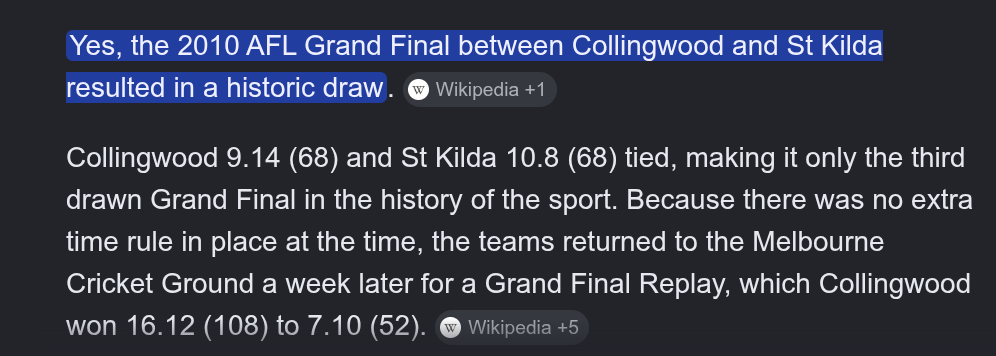

- awesome finding I think



- the same draw logic explains the 4th, 5th, and 6th pair (btw, the 6th pair is a data cleaning Issue i think, the w of west is small, will fix that too). but the second pair (Essendon Bombers VS Carlton Blues, and then Gold Coast Suns), that one does not make any sense, it is not a draw or anything. same for 3rd pair (the goal coast suns one). I will google search these two entries, I think they are a weird anomaly


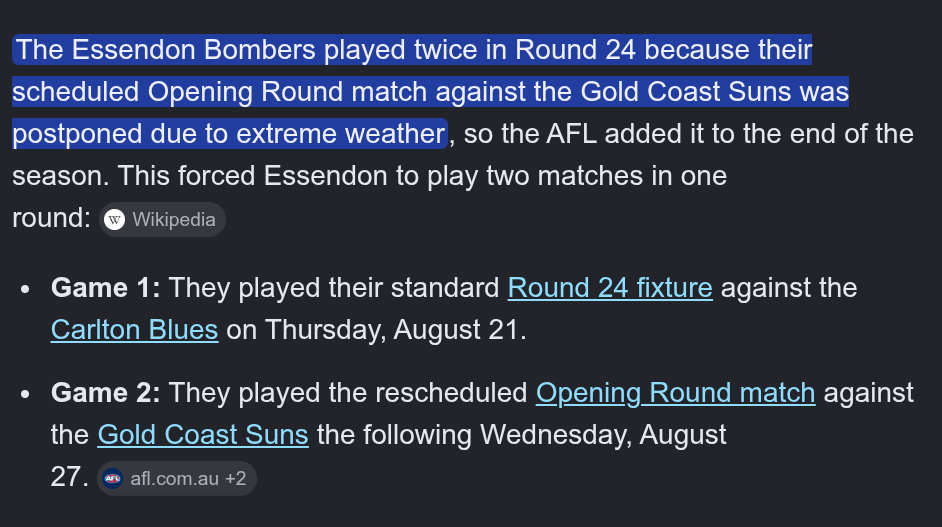
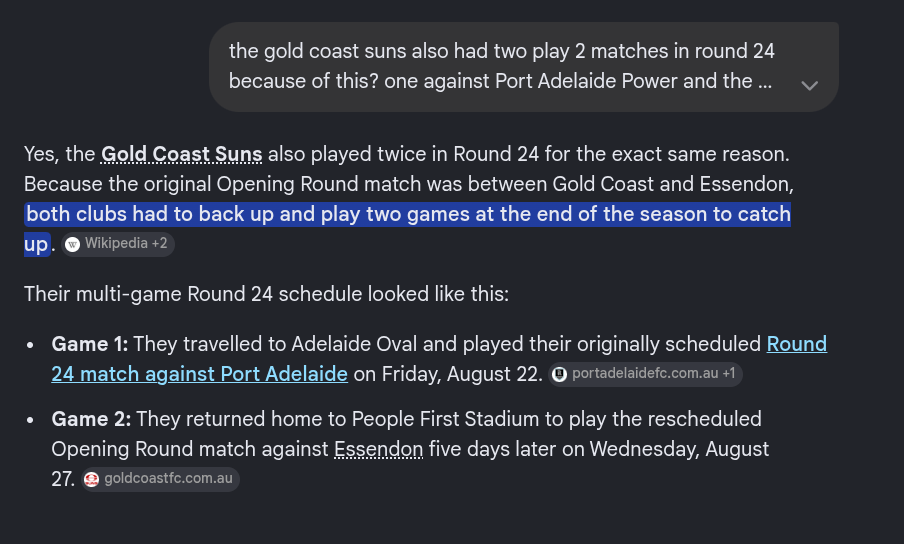


- I think that was the coolest finding everrr, it does make sense, so essendon played 2 matches in 1 round (normally 1 team plays 1 match in 1 round and once all teams are don it would be something like 9 matches total in 1 round) and they played twice becauase their normal match got cancelled becauase of weather. so it all makes sense

- lets fix the opponent column first (additional cleaning step)

In [65]:
match_df["opponent"] = match_df["opponent"].str.strip().str.title()

In [66]:
dups = match_df[match_df.duplicated(subset=["team_name", "year", "round"], keep=False)]
dups

,id,team_name,round,match_date,year,home_away,opponent,team_quarter_scores,team_score,opponent_quarter_scores,opponent_score,result,margin,venue,crowd,team_goals_kicked,team_behinds,opponent_goals_kicked,opponent_behinds
2160,2043,Collingwood Magpies,GF,2010-09-25,2010,H,St Kilda Saints,4.2 7.8 7.13 9.14,68,3.2 4.2 7.5 10.8,68,D,0,Melbourne Cricket Ground,100016.0,9,14,10,8
2161,2044,Collingwood Magpies,GF,2010-10-02,2010,H,St Kilda Saints,3.2 6.5 11.8 16.12,108,0.2 1.8 4.9 7.10,52,W,56,Melbourne Cricket Ground,93853.0,16,12,7,10
3051,2982,Essendon Bombers,24,2025-08-21,2025,H,Carlton Blues,1.4 2.6 5.6 8.8,56,3.4 7.6 11.8 13.12,90,L,-34,Melbourne Cricket Ground,41150.0,8,8,13,12
3052,2983,Essendon Bombers,24,2025-08-27,2025,A,Gold Coast Suns,1.0 3.4 5.6 8.10,58,7.4 9.10 15.15 23.15,153,L,-95,People First Stadium,16768.0,8,10,23,15
4414,4518,Gold Coast Suns,24,2025-08-22,2025,A,Port Adelaide Power,3.6 6.10 7.10 9.13,67,2.2 4.7 8.10 10.11,71,L,-4,Adelaide Oval,40897.0,9,13,10,11
4415,4519,Gold Coast Suns,24,2025-08-27,2025,H,Essendon Bombers,7.4 9.10 15.15 23.15,153,1.0 3.4 5.6 8.10,58,W,95,People First Stadium,16768.0,23,15,8,10
7458,8074,St Kilda Saints,GF,2010-09-25,2010,A,Collingwood Magpies,3.2 4.2 7.5 10.8,68,4.2 7.8 7.13 9.14,68,D,0,Melbourne Cricket Ground,100016.0,10,8,9,14
7459,8075,St Kilda Saints,GF,2010-10-02,2010,A,Collingwood Magpies,0.2 1.8 4.9 7.10,52,3.2 6.5 11.8 16.12,108,L,-56,Melbourne Cricket Ground,93853.0,7,10,16,12
12447,15199,West Coast Eagles,QF,1990-09-08,1990,A,Collingwood Magpies,3.1 6.5 10.10 13.12,90,3.6 7.11 10.12 13.12,90,D,0,Waverley Park,57546.0,13,12,13,12
12448,15200,West Coast Eagles,QF,1990-09-15,1990,A,Collingwood Magpies,2.1 4.5 9.9 9.13,67,8.1 12.6 14.9 19.12,126,L,-59,Waverley Park,53520.0,9,13,19,12


- adding opponent won't help
- adding result also won't help
- match_date will do perfectly (and I think margin as well)
- lets add match_date to our composite key and see if the 6 goes to zero

In [67]:
match_df.duplicated(subset=["team_name", "year", "round", "match_date"]).sum()

np.int64(0)

- that worked perfectly

### 1. **Answer**: My Composite Foreign key that I will use for the merge is team name, year, round, match date

---

## 2. Context Enrichment
Merge the datasets and successfully add the following columns to the Round-by-Round dataset:

- home_away
- venue
- crowd

Validate that the merged information is correct.

In [68]:
round_df["match_date"] = pd.to_datetime(round_df["match_date"])

In [69]:
merged_df = round_df.merge(
    match_df[["team_name", "year", "round", "match_date", "home_away", "venue", "crowd"]],
    left_on=["team", "year", "round", "match_date"],
    right_on=["team_name", "year", "round", "match_date"],
    how="left",
    indicator=True
)
merged_df = merged_df.drop(columns="team_name")

merged_df.head()

,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,margin,home_away,venue,crowd,_merge
0,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,...,0.0,NaN,45552,1994-08-14,36,28,A,Melbourne Cricket Ground,52562.0,both
1,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,0.0,...,0.0,26.0,44356,2024-03-16,23,8,H,GMHBA Stadium,39352.0,both
2,583553,Essendon Bombers,1999,97,Adelaide Crows,10,W,6,14.0,5.0,...,0.0,NaN,45955,1999-06-04,67,48,A,AAMI Stadium,39389.0,both
3,590676,Western Bulldogs,1994,36,St Kilda Saints,21,W,35,12.0,10.0,...,0.0,NaN,45656,1994-08-13,81,45,A,Waverley Park\n,14653.0,both
4,582473,Richmond Tigers,1997,113,Melbourne Demons,10,L,41,4.0,2.0,...,0.0,NaN,45929,1997-05-31,32,-25,H,Melbourne Cricket Ground,28879.0,both


### 2. **Answer**: Merge ran successfully and the 3 columns are now merged into the big round_df

---

## 3. Merge Validation
After merging:

- Check for unmatched records.
- Check for duplicated records introduced by the merge.
- Verify that the number of player records remains unchanged.

Explain any mismatches found.

In [70]:
print("round_df rows:", len(round_df))
print("merged_df rows:", len(merged_df))

print(merged_df["_merge"].value_counts())  # left_only = unmatched player rows

unmatched = merged_df[merged_df["_merge"] == "left_only"]
print(unmatched[["team", "opponent", "year", "round", "match_date"]].drop_duplicates())

merged_df = merged_df.drop(columns="_merge")

round_df rows: 274079
merged_df rows: 274079
_merge
both          274079
left_only          0
right_only         0
Name: count, dtype: int64
Empty DataFrame
Columns: [team, opponent, year, round, match_date]
Index: []


### 3. **Answer**: Same amount of rows on both sides clearly. so we got no duplicates. And **both** is also equal to the entire df size meaning every player row found one matched-row hence we got no unmatched records on either side, if we did then left_only or right_only would be more than zero

---

## 4. Contextual Analysis
Using the enriched dataset, answer questions such as:

- Do players perform better at home or away?
- Does crowd size appear to influence fantasy points?
- Which venues produce the highest average player performance?

Support every conclusion with evidence.

- for the first one, we can just see fantasy points grouped by home_away and see where they are more
- for question 2, does crowd size influence fantasy points, a simple correlation would be enough I think
- for question 3, I could go back to the previous round by round analysis notebook and save that df and use the performance index I made to check performance, but I think comparing fantasy poinst would be enough as well, they are a decent estimate of the performance (and was part of my performance index too)


In [71]:
home_away_perf = merged_df.groupby("home_away")["fantasy_points"].mean()
print(home_away_perf)
print("==============================")

correlation = merged_df[["crowd", "fantasy_points"]].corr()
print(correlation)
print("==============================")

venue_perf = merged_df.groupby("venue")["fantasy_points"].mean().sort_values(ascending=False)
print(venue_perf.head(8))
print("==============================")


home_away
A    64.004408
H    66.485504
Name: fantasy_points, dtype: float64
                   crowd  fantasy_points
crowd           1.000000        0.027876
fantasy_points  0.027876        1.000000
venue
Junction Oval       75.333333
TIO Stadium\n       74.187500
Jiangwan Stadium    72.481752
UTAS Stadium\n      70.879699
Riverway Stadium    70.369565
Westpac Stadium     69.716418
TIO Traeger Park    69.615385
Accor Stadium\n     68.866667
Name: fantasy_points, dtype: float64


another data cleaning bug found, gotta strip and title the venue names

In [72]:
merged_df["venue"] = merged_df["venue"].str.strip().str.title()

### 4. **Answer 4.1**: Players score 2.5 ish more fantasy points on average when they are playing on their home stadium so their performance is mildly better

### 4. **Answer 4.2**: The correlation is 0.028 so its safe to say that No, the size of the crowd does not influence fantasy points significantly

### 4. **Answer 4.3**: Junction Oval gives the best overall fantasy points

- ok, so this is me from the future, the answer of 4.3 is completely wrong, claude was able to point this out to me. I did a google search too to see if Junction Oval and TIO stadium are anywhere near the top


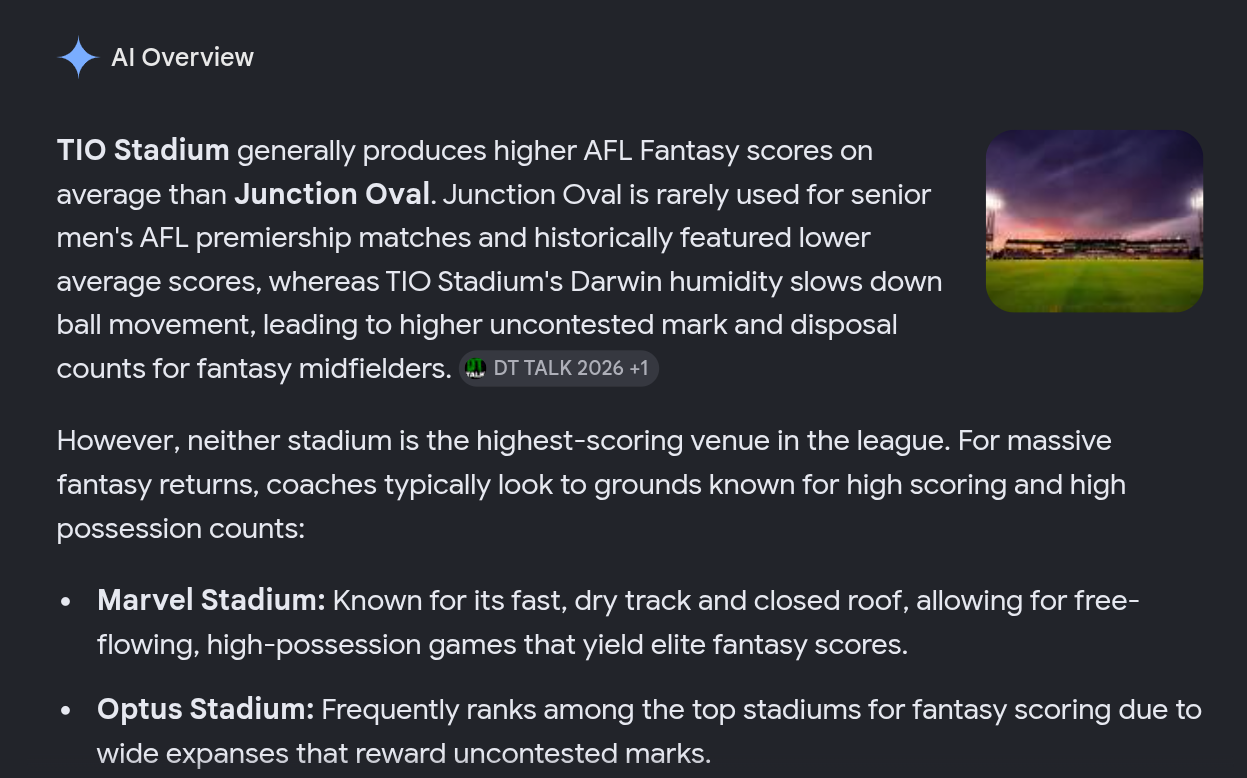


- so the answer is wrong, now to find out why

- ok, the issue is that the venues being ranked high have a way lower sample size as compared to the rest, so venues like junction oval top the chart with low sample size. lets just verify this too

In [73]:
venue_count = merged_df.groupby("venue")["fantasy_points"].count().sort_values()
venue_count.head()

venue
Aegis Park                  1
Junction Oval               3
Bruce Stadium              20
Blacktown International    45
Hands Oval                 46
Name: fantasy_points, dtype: int64

- yes, junction oval literally only has 3 entries. My answer was wrong. Lets actually do the same thing but only compare venues where we have a lot of samples

In [74]:
venue_stats = merged_df.groupby("venue")["fantasy_points"].agg(["mean", "count"])
venue_stats = venue_stats[venue_stats["count"] >= 1000]
venue_stats = venue_stats.sort_values("mean", ascending=False)
print(venue_stats.head(10))

                               mean  count
venue                                     
Utas Stadium              68.051876   4318
Engie Stadium             67.826147   5033
Marvel Stadium            67.570710  51902
Adelaide Oval             67.527898  13173
Tio Stadium               67.102998   1301
Ninja Stadium             67.010731   1957
Optus Stadium             66.123442   8263
People First Stadium      65.964905   9232
Melbourne Cricket Ground  65.455395  69757
Gmhba Stadium             65.239159  11599


ok, that is good I think, let me paste the google search results here as proof


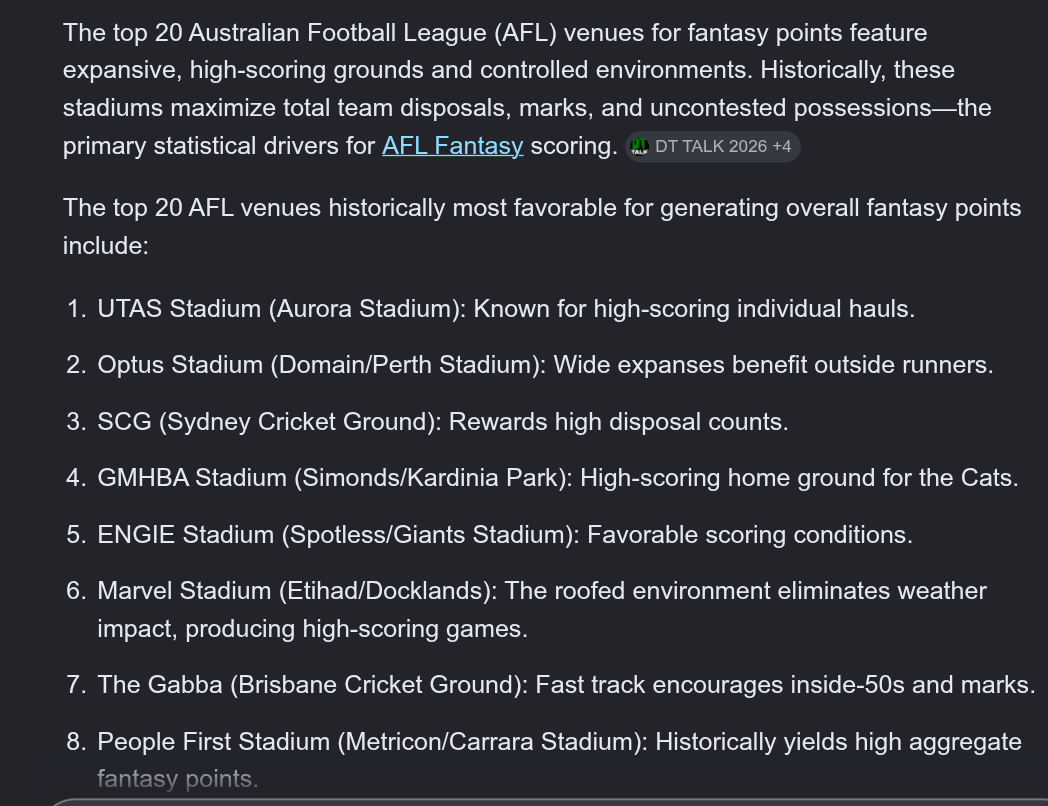

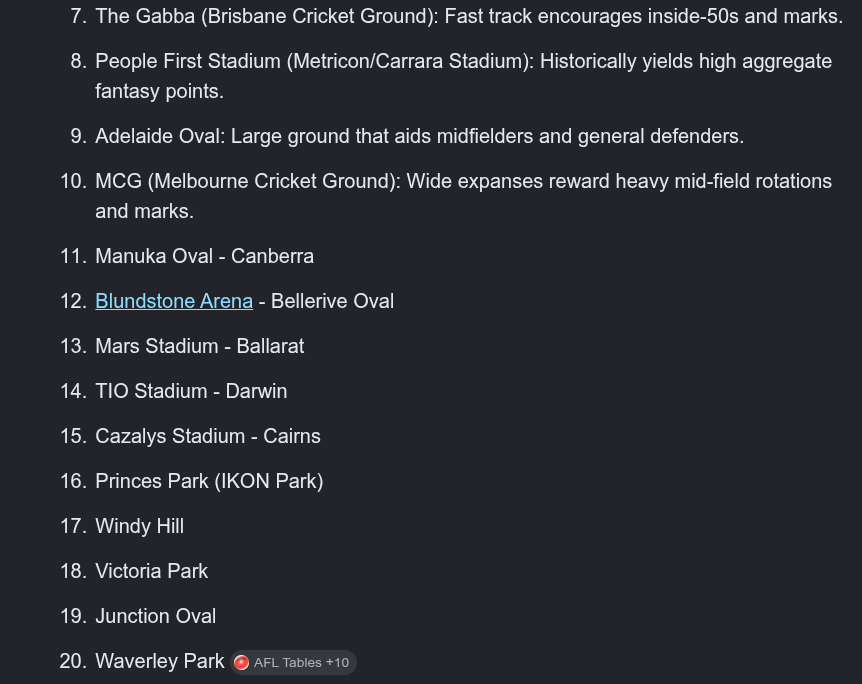

### 4. **Answer 4.3 REDONE**: My results now closely match the google search results and the conclusion is that Utas, MCG, Engie, and Marvel stadiums among others are some of the best for fantasy points

---

## 5. Data Quality Report
Produce a short report describing:

- Merge keys used.
- Challenges encountered.
- Data quality issues discovered.
- Assumptions made during integration.

#### Merge Keys Used:
- Composite Key: Team Name + Match Date + Round + Year
#### Challenges Faced
- No single key could be used as the foreign key
- even with team name, year, and round, it was not enough, because there was the possibility of a draw and the Essendom anomaly, so I had to add match date as well
- Most other challenges were data quality related I guess so will mention it below
#### Data Quality Issues Discovered
- the team name and opponent and venue columns had weird whitespaces and casing
- the crowd column had 398 null values (thanks to COVID)
- Gabba is spelled wrong (still is, I did not bother fixing that, it is irrelevant)
- several venues have very few entries which would skew the results in their favor so took them out for 4.3
#### Assumption made during integration
- I don't think I made any assumption to be honest, I guess the one assumption I made is that fixing the name for the "Gabba Stadium" won't change anything, and it obviously won't
- the other assumptions were mostly trial and error and I did verify most stuff with google searches too, so whatever assumption I made along the way, it never remained an assumption till the end since I validated it.

---